# Extrapolation test

Forecast the next **300 days** of all seven series after the end of the observed dataset using a simple VAR(2) with Gaussian innovations.

The recipe:

1. Load and clean `spiff_data-2.csv` (replace the `1000` sentinels, restrict to the common gap-free window from day 1449).
2. Compute centered simple returns $r_t = P_t / P_{t-1} - 1 - \bar r$.
3. Fit a VAR(2): $r_t = \Phi_1 r_{t-1} + \Phi_2 r_{t-2} + \varepsilon_t$ by OLS, and estimate the residual covariance $\Sigma_\varepsilon$.
4. Seed with the last two observed return vectors and iterate forward for 300 steps using draws $\varepsilon_t \sim \mathcal N(0, \Sigma_\varepsilon)$ via a Cholesky factor.
5. Add the mean back and cumulate to get a price path starting from the last observed price.

This is a deliberately simple version of the DGP — no stochastic volatility, no $t$-copula. The cross-sectional correlation structure comes entirely from $\Sigma_\varepsilon$; the temporal dynamics come from $\Phi_1, \Phi_2$.


## 1. Setup and data loading

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

var_names = ['gurkor', 'guitars', 'slingshots', 'stocks', 'sugar', 'water', 'tranquillity']

df_raw = pd.read_csv('../data/spiff_data-2_filled.csv')

df_raw = df_raw.set_index('day')

df_prices = df_raw[var_names]
print(f"Clean price panel: {df_prices.shape}, days {int(df_prices.index[0])}...{int(df_prices.index[-1])}")
df_prices.tail()

Clean price panel: (5256, 7), days 1...5256


,gurkor,guitars,slingshots,stocks,sugar,water,tranquillity
day,,,,,,,
5252,13.790362,8.236738,6.451460,6.706903,2.972465,8.751953,11.767324
5253,13.798624,8.134064,6.406032,6.677940,2.960002,8.730038,11.830896
5254,13.800276,8.191484,6.444321,6.655631,2.837448,8.748910,12.129688
5255,13.773631,8.123846,6.370987,6.593250,2.851988,8.742213,12.118563
5256,13.791949,8.084917,6.419011,6.512971,2.760591,8.738561,12.231405


## 2. Centered simple returns

We use simple (not log) returns centered at zero, matching the convention used in `500_sim_final.ipynb`. The mean is added back later before cumulating.


In [30]:
df_returns = df_prices.pct_change().dropna()
mean_return = df_returns.mean()
df_returns_centered = df_returns - mean_return
print("Per-series mean return:")
print(mean_return.round(6))
df_returns_centered.head()


Per-series mean return:
gurkor          0.000161
guitars         0.000312
slingshots      0.000317
stocks          0.000017
sugar           0.000079
water           0.000160
tranquillity    0.000165
dtype: float64


,gurkor,guitars,slingshots,stocks,sugar,water,tranquillity
day,,,,,,,
2,0.005521,0.017146,-0.011060,0.001934,0.009196,0.000807,0.003114
3,-0.003551,-0.001516,0.000986,0.013840,-0.005823,-0.000804,0.013315
4,-0.002145,-0.006038,-0.009861,0.002426,-0.014521,0.000806,-0.005002
5,-0.005273,0.003022,0.001435,0.001083,0.004610,0.000913,0.004290
6,0.003264,0.011168,0.004056,-0.004103,-0.000079,0.001233,-0.004197


## 3. Fit VAR(2) by OLS

Stack the regressors $[r_{t-1}, r_{t-2}]$ and solve $r_t = [\Phi_1\;\Phi_2]\,[r_{t-1};\,r_{t-2}] + \varepsilon_t$ jointly via least squares. The residual sample covariance gives $\hat\Sigma_\varepsilon$; its Cholesky factor is the noise driver for the simulation.


In [31]:
Y = df_returns_centered.values                # (T, 7)
T, k = Y.shape

# Build lagged regressors
X = np.column_stack([Y[1:-1], Y[:-2]])        # (T-2, 14): [r_{t-1}, r_{t-2}]
Y_t = Y[2:]                                   # (T-2, 7)

# OLS: B has shape (14, 7); rows 0..6 -> Phi1^T, rows 7..13 -> Phi2^T
B, *_ = np.linalg.lstsq(X, Y_t, rcond=None)
Phi1 = B[:k].T
Phi2 = B[k:].T

# Residual covariance
resid = Y_t - X @ B
Sigma_eps = np.cov(resid, rowvar=False)
L_eps = np.linalg.cholesky(Sigma_eps + 1e-12 * np.eye(k))

print("Phi1 diagonal:", np.round(np.diag(Phi1), 3))
print("Phi2 diagonal:", np.round(np.diag(Phi2), 3))
print(f"Residual std (per series): {np.round(np.sqrt(np.diag(Sigma_eps)), 5)}")


Phi1 diagonal: [-0.012 -0.133 -0.085 -0.001 -0.165 -0.116 -0.034]
Phi2 diagonal: [-0.049 -0.046  0.015 -0.015 -0.06  -0.023 -0.017]
Residual std (per series): [0.00392 0.01446 0.01457 0.01482 0.01346 0.00345 0.01244]


### Stability check

For a VAR(2) the companion matrix $\begin{bmatrix}\Phi_1 & \Phi_2\\ I & 0\end{bmatrix}$ must have all eigenvalues inside the unit circle. Otherwise the forecast will blow up.


In [32]:
companion = np.block([[Phi1, Phi2], [np.eye(k), np.zeros((k, k))]])
eigs = np.linalg.eigvals(companion)
print(f"Max |eigenvalue| of companion: {np.max(np.abs(eigs)):.4f}")
assert np.max(np.abs(eigs)) < 1, "VAR(2) is non-stationary"


Max |eigenvalue| of companion: 0.2799


## 4. Extrapolate 300 days

Seed with the last two observed return vectors $r_{T-1}, r_T$ and roll the VAR forward, drawing $\varepsilon_t = L\,z_t$ with $z_t \sim \mathcal N(0, I)$ at each step.


In [33]:
np.random.seed(7)
H = 1000

last_price = df_prices.iloc[-1].values
last_day = int(df_prices.index[-1])

Y_extrap = np.zeros((H + 2, k))
Y_extrap[0] = Y[-2]
Y_extrap[1] = Y[-1]
for t in range(2, H + 2):
    eps =  L_eps @ np.random.randn(k)
    Y_extrap[t] = Phi1 @ Y_extrap[t - 1] + Phi2 @ Y_extrap[t - 2] + eps

# Add the mean back, cumulate from the last observed price
returns_extrap = Y_extrap[2:] + mean_return.values
prices_extrap = last_price * np.cumprod(1.0 + returns_extrap, axis=0)
future_days = np.arange(last_day + 1, last_day + 1 + H)
df_extrap = pd.DataFrame(prices_extrap, index=future_days, columns=var_names)
df_extrap.index.name = 'day'
df_extrap.head()


,gurkor,guitars,slingshots,stocks,sugar,water,tranquillity
day,,,,,,,
5257,13.887476,8.008653,6.360751,6.542501,2.738954,8.773535,12.193601
5258,13.792457,8.180620,6.499578,6.488390,2.739611,8.758147,12.218436
5259,13.778241,8.043685,6.470970,6.493379,2.773346,8.713028,12.470471
5260,13.791717,7.998533,6.604168,6.496352,2.708043,8.706592,12.130337
5261,13.849444,7.994958,6.493131,6.585448,2.662143,8.740160,11.805486


## 5. Plot observed tail + extrapolation

Blue is the last 500 days of observed prices, orange is the 300-day extrapolation. The dashed grey line marks the splice point.


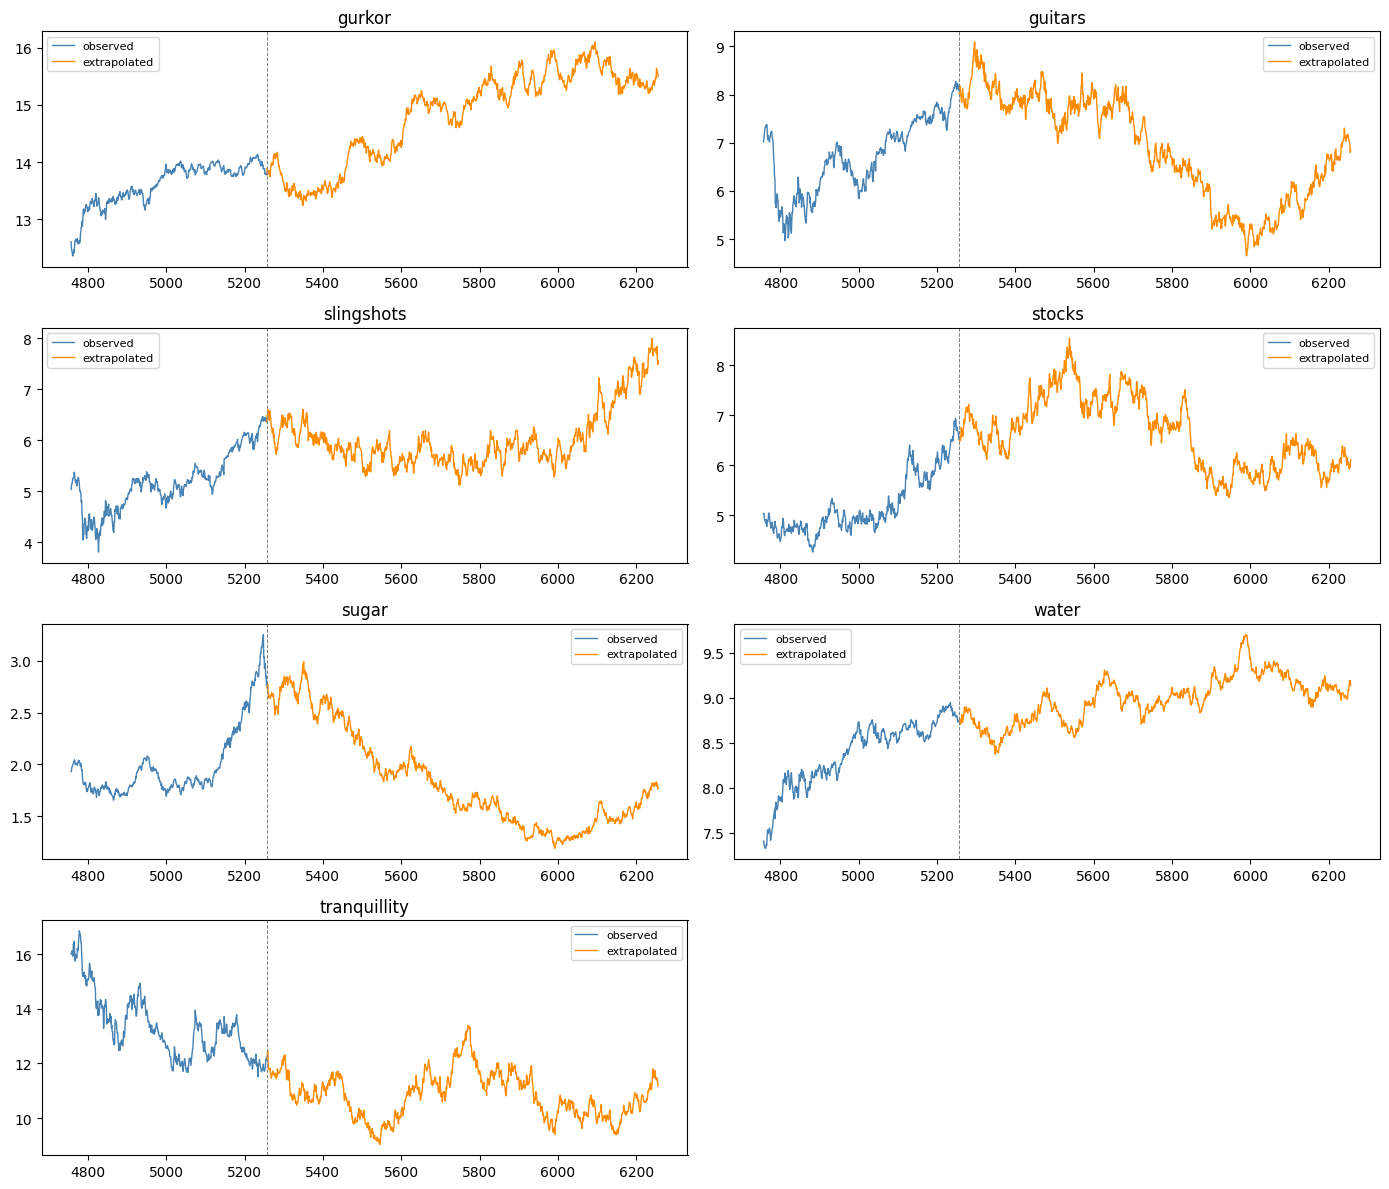

In [34]:
fig, axes = plt.subplots(4, 2, figsize=(14, 12))
tail = 500
for ax, col in zip(axes.flat, var_names):
    ax.plot(df_prices.index[-tail:], df_prices[col].iloc[-tail:],
            color='steelblue', lw=1, label='observed')
    ax.plot(df_extrap.index, df_extrap[col],
            color='darkorange', lw=1, label='extrapolated')
    ax.axvline(last_day, color='grey', lw=0.7, ls='--')
    ax.set_title(col)
    ax.legend(loc='best', fontsize=8)
axes.flat[-1].axis('off')
plt.tight_layout()
plt.show()


## 6. Sanity check: simulated vs. observed return moments

A quick comparison of per-series standard deviations and the cross-sectional correlation matrix. Because the innovations are Gaussian and homoskedastic, we don't expect the simulation to match the heavy tails or volatility clustering of the original — just the linear dependence and unconditional variance.


In [35]:
compare = pd.DataFrame({
    'obs_std':  df_returns_centered.std(),
    'sim_std':  pd.Series(Y_extrap[2:].std(axis=0), index=var_names),
})
print(compare.round(5))

print("\nObserved correlation:")
obs_corr = df_returns_centered.corr()
print(obs_corr.round(2))

print("\nSimulated correlation (300 days — noisy):")
sim_corr = pd.DataFrame(Y_extrap[2:], columns=var_names).corr()
print(sim_corr.round(2))

# Calculate MAE for correlation matrices
mae_corr = np.abs(obs_corr - sim_corr).values.mean()
print(f"\nMAE (correlation matrices): {mae_corr:.5f}")

              obs_std  sim_std
gurkor        0.00393  0.00384
guitars       0.01482  0.01477
slingshots    0.01464  0.01487
stocks        0.01484  0.01452
sugar         0.01512  0.01469
water         0.00350  0.00342
tranquillity  0.01251  0.01248

Observed correlation:
              gurkor  guitars  slingshots  stocks  sugar  water  tranquillity
gurkor          1.00    -0.24       -0.22   -0.04  -0.07   0.57         -0.14
guitars        -0.24     1.00        0.53    0.01   0.21  -0.23          0.22
slingshots     -0.22     0.53        1.00    0.01   0.12  -0.20          0.19
stocks         -0.04     0.01        0.01    1.00  -0.02  -0.04          0.01
sugar          -0.07     0.21        0.12   -0.02   1.00  -0.07          0.13
water           0.57    -0.23       -0.20   -0.04  -0.07   1.00         -0.16
tranquillity   -0.14     0.22        0.19    0.01   0.13  -0.16          1.00

Simulated correlation (300 days — noisy):
              gurkor  guitars  slingshots  stocks  sugar  wate

### Q-Q plot: VAR residuals vs Normal

The Gaussian simulator draws innovations from $\mathcal N(0, \Sigma_\varepsilon)$, so the assumption it stands or falls on is that the *VAR(2) residuals* are Gaussian. Plot the standardized residuals against Normal quantiles per series — any deviation in the tails is exactly what the Gaussian path simulation will fail to reproduce.

Reading the plot: points on the diagonal = perfect Gaussian. Points curving *above* the line in the right tail and *below* in the left = heavier tails than Normal (more extreme observations than a Gaussian would produce). The slope at the centre is fixed by standardization, so any curvature is purely tail behaviour.

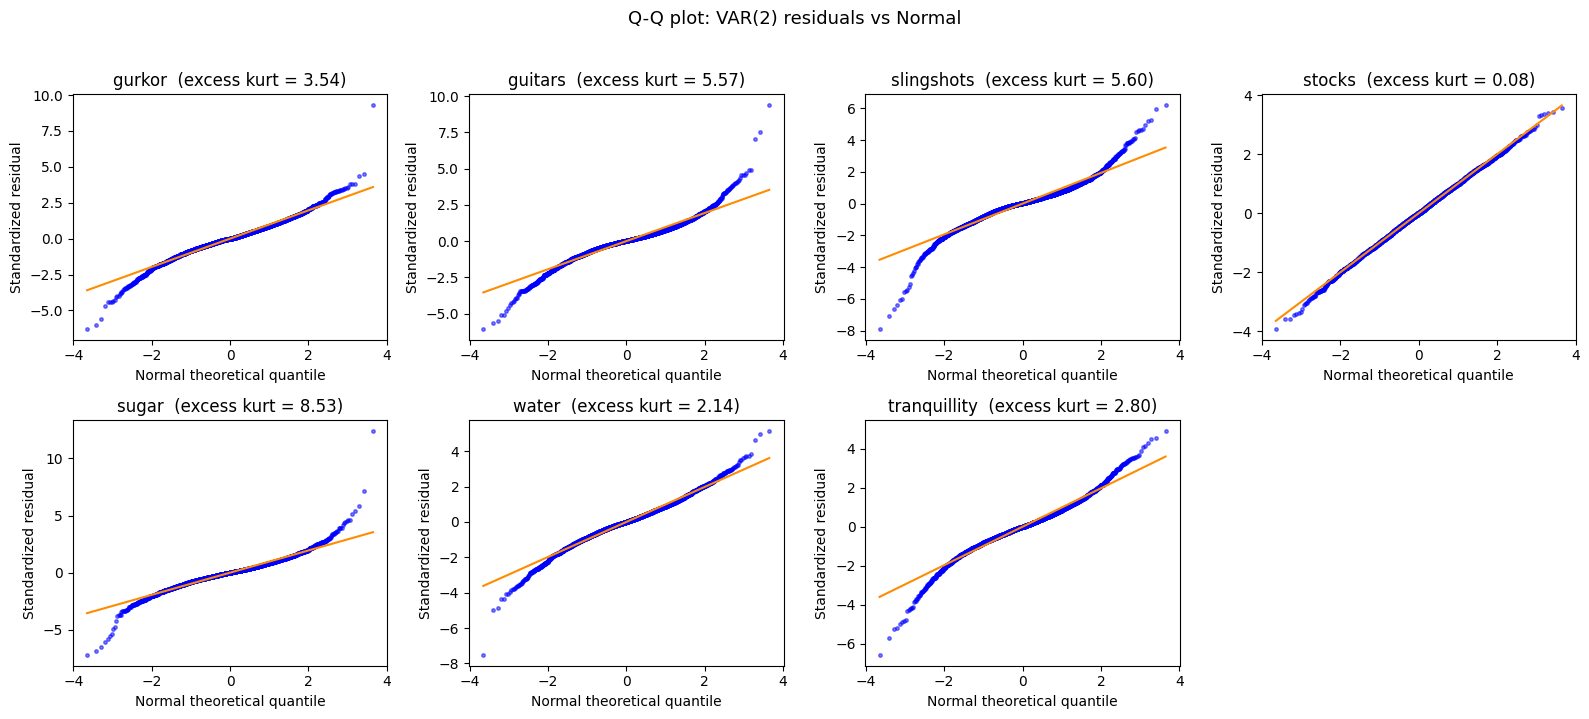

In [36]:
from scipy import stats

resid_std = resid / resid.std(axis=0)  # standardize each column to unit variance

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col, j in zip(axes.flat, var_names, range(k)):
    stats.probplot(resid_std[:, j], dist='norm', plot=ax)
    ax.set_title(f"{col}  (excess kurt = {pd.Series(resid[:, j]).kurt():.2f})")
    ax.get_lines()[0].set_markersize(2.5)
    ax.get_lines()[0].set_alpha(0.5)
    ax.get_lines()[1].set_color('darkorange')
    ax.set_xlabel('Normal theoretical quantile')
    ax.set_ylabel('Standardized residual')
axes.flat[-1].axis('off')
plt.suptitle('Q-Q plot: VAR(2) residuals vs Normal', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

## 7. Conditional variance (GARCH) correlation

Fit a GARCH(1,1) with zero mean to each series, both on the observed returns and on the 300-day extrapolation, then compare the cross-sectional correlation of the log conditional variances. This is the structure the full DGP in `500_sim_final.ipynb` works hard to recover via PCA on log-vol; here we expect the simple homoskedastic VAR to **miss it almost entirely** — conditional vol on the simulated path is driven only by the rolling sample variance of the VAR residuals, which is i.i.d. by construction. The interesting question is *how much* signal survives anyway.


Off-diagonal MAE on log-vol correlations: 0.508


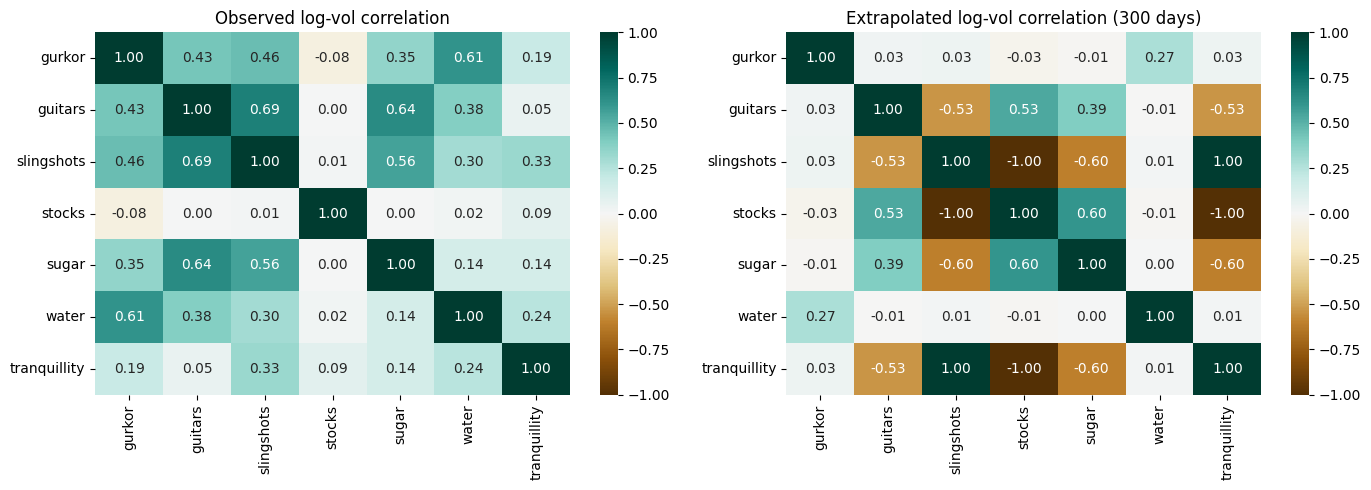

In [37]:
from arch import arch_model

def fit_log_h(returns_df):
    out = pd.DataFrame(index=returns_df.index, columns=returns_df.columns, dtype=float)
    for col in returns_df.columns:
        # scale up to keep the optimizer happy (arch prefers ~1-sized series)
        res = arch_model(returns_df[col] * 1000, vol='Garch', p=1, q=1, mean='Zero').fit(disp='off')
        out[col] = np.log(res.conditional_volatility ** 2)
    return out 

# Observed: use the same centered returns we trained the VAR on
log_h_obs = fit_log_h(df_returns_centered)

# Simulated: rebuild centered returns from the extrapolation
df_sim_returns = pd.DataFrame(Y_extrap[2:], index=future_days, columns=var_names)
log_h_sim = fit_log_h(df_sim_returns)

corr_obs = log_h_obs.corr()
corr_sim = log_h_sim.corr()

mask = ~np.eye(k, dtype=bool)
mae_vol_corr = np.mean(np.abs(corr_obs.values[mask] - corr_sim.values[mask]))
print(f"Off-diagonal MAE on log-vol correlations: {mae_vol_corr:.3f}")

import seaborn as sns
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(corr_obs, annot=True, fmt='.2f', cmap='BrBG', center=0,
            vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title('Observed log-vol correlation')
sns.heatmap(corr_sim, annot=True, fmt='.2f', cmap='BrBG', center=0,
            vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title('Extrapolated log-vol correlation (300 days)')
plt.tight_layout()
plt.show()


### What this shows

The observed panel has strong shared volatility (gurkor / guitars / slingshots / sugar / water cluster tightly). The extrapolation can't reproduce it, because its innovations are i.i.d. Gaussian — any apparent vol correlation on the simulated path is sampling noise from 300 observations, not structure. This is the headline limitation of the simple version and the reason `500_sim_final.ipynb` adds PCA-on-log-vol factors.

## Other tests worth running

If you want to push this further, the most informative additions would be:

- **Marginal tails / kurtosis.** Compare per-series excess kurtosis and run a Q–Q plot of simulated vs. observed standardized returns. The Gaussian VAR will visibly under-produce tails.
- **ARCH-LM test** (`statsmodels.stats.diagnostic.het_arch`) on returns and on the VAR(2) residuals — quantifies the volatility clustering the simulation is missing.
- **Squared-return ACF.** Plot $\mathrm{ACF}(r_t^2)$ for observed vs. simulated; observed will show slow decay (long memory in vol), simulated will be flat — a clean visual of the same gap.
- **Ljung–Box on residuals.** Confirms the VAR(2) has soaked up the linear autocorrelation (no remaining mean structure). If it hasn't, raise the order.
- **Forecast-fan check.** Run the extrapolation 200–1000 times with different seeds and overlay the price paths to show the simulated uncertainty cone; compare its width at $H=300$ to a bootstrap of 300-day windows from the observed data.
- **Impulse response stability.** Plot the IRF of each series to a unit shock in each other series — sanity-check that the fitted $\Phi_1, \Phi_2$ match the hardcoded ones in `500_sim_final.ipynb`.
- **In-sample backtest.** Hold out the last 300 observed days, refit on the rest, extrapolate, and compare to truth (RMSE on prices, calibration of forecast intervals from a Monte Carlo).

The backtest and the squared-return ACF would probably give you the most insight per minute of work.


## 8. Multivariate-t innovations (EM fit)

Replace the Gaussian draws with a Gaussian scale mixture:

$$ \varepsilon_t = \sqrt{\nu / G_t}\; L\, z_t,\quad z_t \sim \mathcal N(0, I),\quad G_t \sim \chi^2_\nu $$

This is the multivariate-$t$ with shape $\Sigma$ and dof $\nu$. A *single* scale $G_t$ is shared across all seven series, so heavy-tail days inflate every series simultaneously — that recovers some of the contemporaneous vol co-movement that the homoskedastic Gaussian VAR misses.

**Estimation by EM.** Write the MV-$t$ as $\varepsilon_t \mid \tau_t \sim \mathcal N(0, \Sigma/\tau_t)$ with $\tau_t \sim \mathrm{Gamma}(\nu/2, \nu/2)$. Treating $\tau_t$ as latent gives:

- **E-step**: $w_t = \mathbb E[\tau_t \mid \varepsilon_t] = (\nu+k)/(\nu + d_t^2)$ and $\xi_t = \mathbb E[\log\tau_t \mid \varepsilon_t] = \psi((\nu+k)/2) - \log((\nu+d_t^2)/2)$, where $d_t^2 = \varepsilon_t^\top \Sigma^{-1} \varepsilon_t$.
- **M-step**: $\Sigma_{\text{new}} = T^{-1} \sum_t w_t\, \varepsilon_t \varepsilon_t^\top$ (weighted sample covariance — down-weights tail obs, so it's a robust scatter), and $\nu$ is the root of $-\psi(\nu/2) + \log(\nu/2) + 1 + \overline{\xi - w} = 0$.

This avoids the two failure modes of the MoM estimator we had before:

1. Mahalanobis MoM gave $\bar d^2 \equiv k$ by algebraic identity (because $\Sigma$ was the sample covariance of the same residuals), so the estimator was degenerate and silently clamped to 4.5.
2. EM's $\Sigma$ is robust, so $\bar d^2$ is no longer pinned to $k$, and $\nu$ is identified from the likelihood directly.

After fitting, simulate with $\varepsilon = \sqrt{\nu/G}\, L z$ where $L L^\top = \hat\Sigma$. Under MV-$t$, $\mathrm{Cov}(\varepsilon) = \tfrac{\nu}{\nu-2}\hat\Sigma$, so no manual rescaling of the Cholesky factor is needed — the model handles it.

In [38]:
from scipy.stats import chi2
from scipy.special import digamma
from scipy.optimize import brentq


def fit_mvt_em(X, nu_init=10.0, tol=1e-7, max_iter=500, verbose=False):
    """EM for zero-mean multivariate-t. Returns (Sigma_shape, nu, n_iter)."""
    T, k = X.shape
    Sigma = np.cov(X, rowvar=False)
    nu = nu_init
    for it in range(1, max_iter + 1):
        # E-step
        Sigma_inv = np.linalg.inv(Sigma)
        d2 = np.einsum('ti,ij,tj->t', X, Sigma_inv, X)
        w  = (nu + k) / (nu + d2)
        xi = digamma((nu + k) / 2.0) - np.log((nu + d2) / 2.0)

        # M-step: Sigma (weighted sample cov)
        Sigma_new = (X * w[:, None]).T @ X / T

        # M-step: nu via 1-D root of d/dnu Q(nu) = 0
        c = np.mean(xi - w)
        f = lambda v: -digamma(v / 2.0) + np.log(v / 2.0) + 1.0 + c
        try:
            nu_new = brentq(f, 2.001, 500.0, xtol=1e-6)
        except ValueError:
            nu_new = 500.0  # tails essentially Gaussian

        delta = max(np.max(np.abs(Sigma_new - Sigma)), abs(nu_new - nu))
        Sigma, nu = Sigma_new, nu_new
        if verbose and it % 10 == 0:
            print(f"  iter {it:3d}: nu={nu:.4f}, delta={delta:.2e}")
        if delta < tol:
            break
    return Sigma, nu, it


Sigma_shape, nu_hat, n_iter = fit_mvt_em(resid, verbose=False)
print(f"EM converged in {n_iter} iterations: nu_hat = {nu_hat:.3f}")

# Sanity: model-implied covariance vs sample covariance of residuals
implied_cov = nu_hat / (nu_hat - 2.0) * Sigma_shape
print(f"max |Cov_model - Cov_sample| = {np.max(np.abs(implied_cov - Sigma_eps)):.2e}")
print(f"diag ratio (model / sample): {np.round(np.diag(implied_cov) / np.diag(Sigma_eps), 3)}")

# Cholesky of the EM-fitted shape matrix — no manual rescaling
L_mvt = np.linalg.cholesky(Sigma_shape + 1e-12 * np.eye(k))

np.random.seed(7)
Y_extrap_t = np.zeros((H + 2, k))
Y_extrap_t[0] = Y[-2]
Y_extrap_t[1] = Y[-1]
for t in range(2, H + 2):
    g   = chi2.rvs(nu_hat)
    eps = np.sqrt(nu_hat / g) * (L_mvt @ np.random.randn(k))
    Y_extrap_t[t] = Phi1 @ Y_extrap_t[t - 1] + Phi2 @ Y_extrap_t[t - 2] + eps

returns_extrap_t = Y_extrap_t[2:] + mean_return.values
prices_extrap_t  = last_price * np.cumprod(1.0 + returns_extrap_t, axis=0)
df_extrap_t = pd.DataFrame(prices_extrap_t, index=future_days, columns=var_names)
df_extrap_t.index.name = 'day'

EM converged in 61 iterations: nu_hat = 6.595
max |Cov_model - Cov_sample| = 5.02e-05
diag ratio (model / sample): [0.972 0.873 0.871 1.229 0.96  1.004 1.026]


### Compare: kurtosis and vol correlation, Gaussian vs MV-t

Excess kurtosis:
                obs  sim_gauss  sim_mvt
gurkor         3.61       0.09     2.01
guitars        6.08       0.13     2.21
slingshots     6.08       0.09     2.46
stocks         0.09      -0.07     2.18
sugar         12.08      -0.22     0.93
water          2.26      -0.14     2.69
tranquillity   2.86      -0.06     1.20

Log-vol correlation MAE — Gaussian: 0.508   MV-t: 0.361


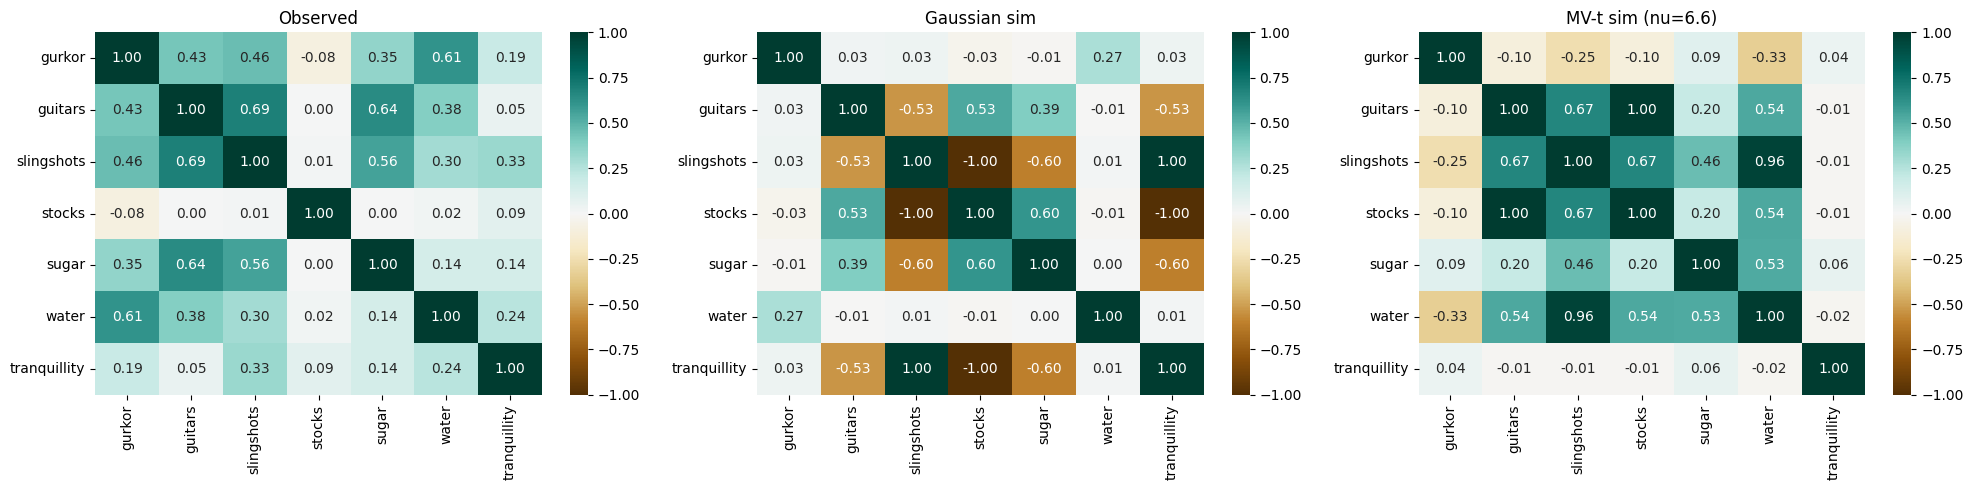

In [39]:
# Marginal kurtosis comparison
kurt = pd.DataFrame({
    'obs':       df_returns_centered.kurt(),
    'sim_gauss': pd.DataFrame(Y_extrap[2:],   columns=var_names).kurt(),
    'sim_mvt':   pd.DataFrame(Y_extrap_t[2:], columns=var_names).kurt(),
})
print("Excess kurtosis:")
print(kurt.round(2))

# Refit GARCH on MV-t simulation, compare log-vol correlation
df_sim_returns_t = pd.DataFrame(Y_extrap_t[2:], index=future_days, columns=var_names)
log_h_sim_t = fit_log_h(df_sim_returns_t)
corr_sim_t = log_h_sim_t.corr()

mae_gauss = np.mean(np.abs(corr_obs.values[mask] - corr_sim.values[mask]))
mae_mvt   = np.mean(np.abs(corr_obs.values[mask] - corr_sim_t.values[mask]))
print(f"\nLog-vol correlation MAE — Gaussian: {mae_gauss:.3f}   MV-t: {mae_mvt:.3f}")

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
sns.heatmap(corr_obs,   annot=True, fmt='.2f', cmap='BrBG', center=0,
            vmin=-1, vmax=1, ax=axes[0]); axes[0].set_title('Observed')
sns.heatmap(corr_sim,   annot=True, fmt='.2f', cmap='BrBG', center=0,
            vmin=-1, vmax=1, ax=axes[1]); axes[1].set_title('Gaussian sim')
sns.heatmap(corr_sim_t, annot=True, fmt='.2f', cmap='BrBG', center=0,
            vmin=-1, vmax=1, ax=axes[2]); axes[2].set_title(f'MV-t sim (nu={nu_hat:.1f})')
plt.tight_layout()
plt.show()


## 9. Moment-based tail CIs (Cornish-Fisher) vs. rolling-empirical

**Idea.** Use Gaussian-VAR paths for the body of the distribution (50–80% CIs) and a separate, distribution-free moment-based estimator for the tails (95 / 99 / 99.9%). The Cornish-Fisher expansion converts the first four sample moments — $(\mu, \sigma, S, K)$ — into quantile corrections on top of the Normal quantile $z_\alpha$:

$$q_\alpha \approx z_\alpha + \tfrac{1}{6}(z_\alpha^2 - 1)S + \tfrac{1}{24}(z_\alpha^3 - 3z_\alpha)K - \tfrac{1}{36}(2z_\alpha^3 - 5z_\alpha)S^2$$

For an $H$-day horizon under i.i.d. returns: $\mu_H = H\mu$, $\sigma_H^2 = H\sigma^2$, $S_H = S/\sqrt H$, $K_H = K/H$.

We compare three estimates of the $H=200$-day log-return distribution per series:

1. **Gaussian-only**: $\mu_H \pm z_\alpha \sigma_H$ (the baseline the VAR sim is consistent with).
2. **Cornish-Fisher**: same $\mu_H, \sigma_H$, but quantiles corrected by sample $S, K$ of daily log returns, scaled to 200-day under i.i.d.
3. **Rolling-empirical**: every overlapping 200-day window of historical log returns, then read off the empirical quantile directly. No distributional or i.i.d. assumption — this is the ground truth.

Where (2) and (3) agree, moments are sufficient. Where they diverge, path dynamics (vol clustering, persistent extremes) are doing something a moment-based model can't see.

In [40]:
from scipy.stats import norm, skew, kurtosis

H_tail = 200
alphas = [0.001, 0.01, 0.05, 0.10, 0.50, 0.90, 0.95, 0.99, 0.999]
z = {a: norm.ppf(a) for a in alphas}

def cornish_fisher_q(z_a, S, K):
    return (z_a
            + (z_a**2 - 1) * S / 6
            + (z_a**3 - 3*z_a) * K / 24
            - (2*z_a**3 - 5*z_a) * S**2 / 36)

log_ret = np.log(df_prices).diff().dropna()

records = []
for col in var_names:
    r = log_ret[col].values
    mu, sd = r.mean(), r.std(ddof=1)
    S, K   = skew(r), kurtosis(r)            # K is excess by default

    mu_H = H_tail * mu
    sd_H = np.sqrt(H_tail) * sd
    S_H  = S / np.sqrt(H_tail)
    K_H  = K / H_tail

    # Rolling-empirical: every overlapping 200-day log-return sum
    roll = pd.Series(r).rolling(H_tail).sum().dropna().values

    row = {'series': col, 'mu_H': mu_H, 'sd_H': sd_H, 'S_H': S_H, 'K_H': K_H,
           'n_windows': len(roll)}
    for a in alphas:
        row[f'gauss_{int(a*1000)/10}'] = mu_H + sd_H * z[a]
        row[f'cf_{int(a*1000)/10}']    = mu_H + sd_H * cornish_fisher_q(z[a], S_H, K_H)
        row[f'emp_{int(a*1000)/10}']   = np.quantile(roll, a)
    records.append(row)

tail_df = pd.DataFrame(records).set_index('series')

# Pretty-print the asymmetric tail quantiles as price-multiples (exp of log return)
def fmt_block(qs):
    sub = tail_df[[f'{m}_{q}' for m in ['gauss','cf','emp'] for q in qs]]
    sub = np.exp(sub)  # convert log-return to price multiple of P_0
    return sub.round(3)

print("200-day price-multiple quantiles (P_T / P_0), left tail:")
print(fmt_block(['0.1', '1.0', '5.0']))
print("\n200-day price-multiple quantiles, right tail:")
print(fmt_block(['95.0', '99.0', '99.9']))
print("\nMedian (50%) — sanity check that drift agrees across methods:")
print(fmt_block(['50.0']))

200-day price-multiple quantiles (P_T / P_0), left tail:
              gauss_0.1  gauss_1.0  gauss_5.0  cf_0.1  cf_1.0  cf_5.0  \
series                                                                  
gurkor            0.869      0.906      0.941   0.867   0.906   0.941   
guitars           0.545      0.640      0.738   0.542   0.639   0.738   
slingshots        0.549      0.643      0.741   0.541   0.639   0.740   
stocks            0.513      0.602      0.695   0.511   0.601   0.694   
sugar             0.513      0.604      0.698   0.505   0.600   0.698   
water             0.885      0.919      0.951   0.884   0.918   0.950   
tranquillity      0.588      0.674      0.760   0.584   0.672   0.759   

              emp_0.1  emp_1.0  emp_5.0  
series                                   
gurkor          0.902    0.916    0.942  
guitars         0.480    0.530    0.660  
slingshots      0.496    0.635    0.751  
stocks          0.528    0.593    0.690  
sugar           0.516    0.588   

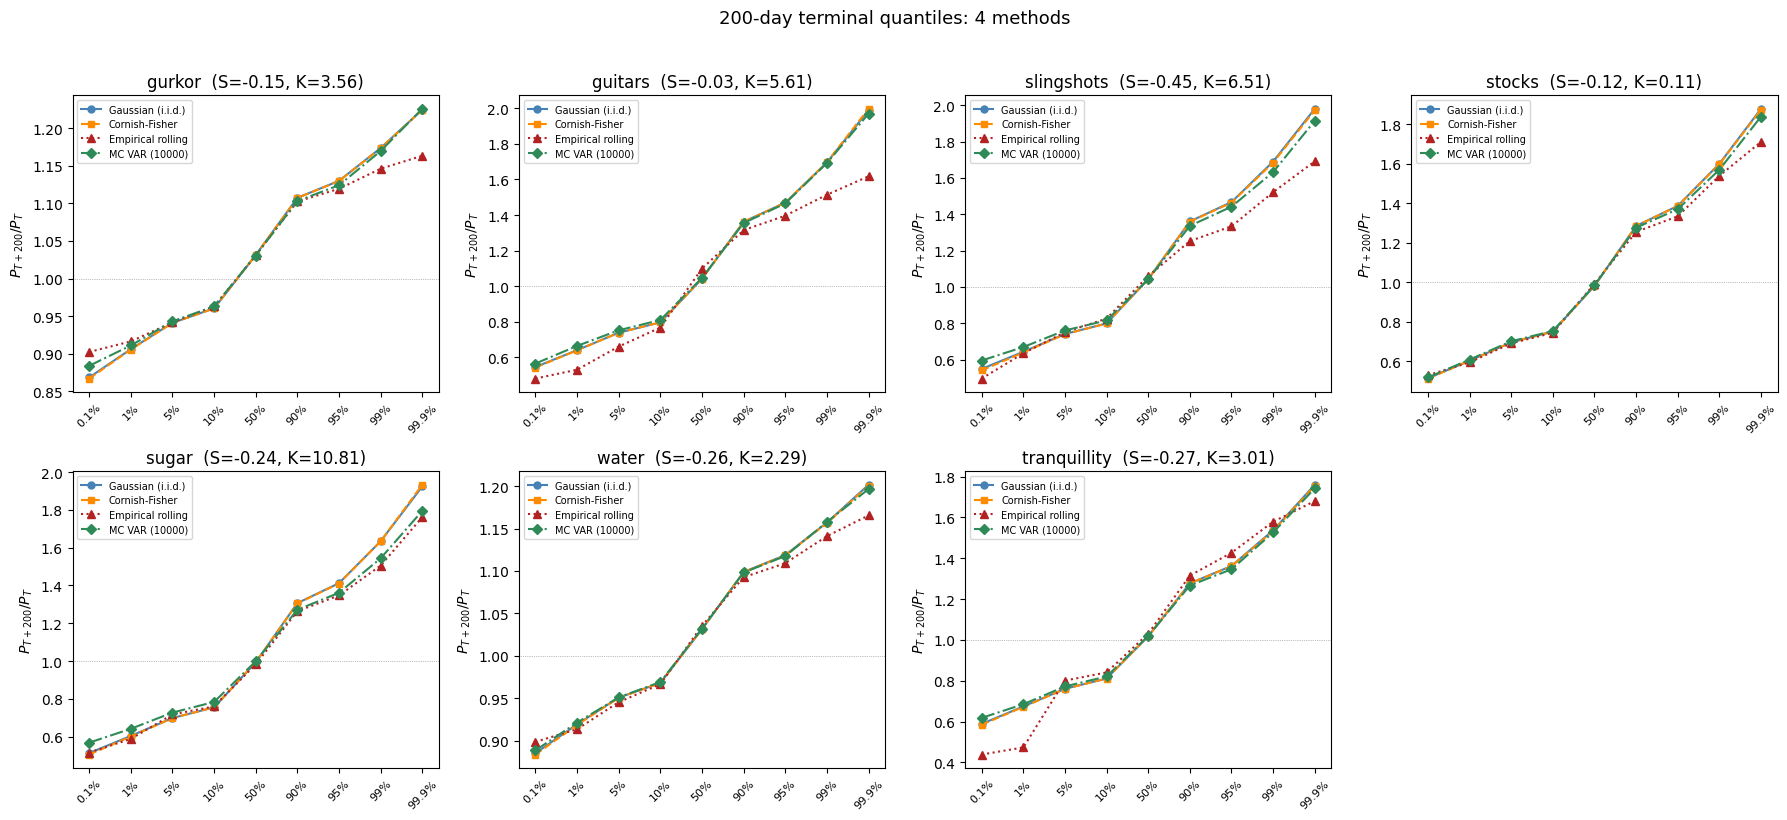

In [43]:
# Monte Carlo: run the Gaussian VAR sim n_mc times over H_tail days.
# Save full price paths and terminal log returns so we can build both
# quantile fans (over time) and point quantiles (at H_tail).
n_mc = 10000
rng_mc = np.random.default_rng(42)

mc_prices = np.zeros((n_mc, H_tail, k))
mc_term_log_ret = np.zeros((n_mc, k))

for s in range(n_mc):
    Yp = np.zeros((H_tail + 2, k))
    Yp[0] = Y[-2]
    Yp[1] = Y[-1]
    for t in range(2, H_tail + 2):
        eps = L_eps @ rng_mc.standard_normal(k)
        Yp[t] = Phi1 @ Yp[t - 1] + Phi2 @ Yp[t - 2] + eps
    simple_ret_path = Yp[2:] + mean_return.values
    price_path = last_price * np.cumprod(1.0 + simple_ret_path, axis=0)
    mc_prices[s] = price_path
    mc_term_log_ret[s] = np.log(price_path[-1] / last_price)

# Add MC terminal quantiles to the comparison table
for j, col in enumerate(var_names):
    for a in alphas:
        tail_df.loc[col, f'mc_{int(a*1000)/10}'] = np.quantile(mc_term_log_ret[:, j], a)

# Plot all four methods side by side
fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharey=False)
alpha_plot = [0.001, 0.01, 0.05, 0.10, 0.50, 0.90, 0.95, 0.99, 0.999]
x_pos = np.arange(len(alpha_plot))

for ax, col in zip(axes.flat, var_names):
    g  = [np.exp(tail_df.loc[col, f'gauss_{int(a*1000)/10}']) for a in alpha_plot]
    cf = [np.exp(tail_df.loc[col, f'cf_{int(a*1000)/10}'])    for a in alpha_plot]
    em = [np.exp(tail_df.loc[col, f'emp_{int(a*1000)/10}'])   for a in alpha_plot]
    mc = [np.exp(tail_df.loc[col, f'mc_{int(a*1000)/10}'])    for a in alpha_plot]
    ax.plot(x_pos, g,  'o-',  color='steelblue',  label='Gaussian (i.i.d.)', ms=5)
    ax.plot(x_pos, cf, 's--', color='darkorange', label='Cornish-Fisher',    ms=5)
    ax.plot(x_pos, em, '^:',  color='firebrick',  label='Empirical rolling', ms=6)
    ax.plot(x_pos, mc, 'D-.', color='seagreen',   label=f'MC VAR ({n_mc})',  ms=5)
    ax.set_xticks(x_pos)
    ax.set_xticklabels([f'{a*100:g}%' for a in alpha_plot], rotation=45, fontsize=8)
    ax.axhline(1.0, color='grey', lw=0.5, ls=':')
    ax.set_title(f"{col}  (S={tail_df.loc[col,'S_H']*np.sqrt(H_tail):.2f}, "
                 f"K={tail_df.loc[col,'K_H']*H_tail:.2f})")
    ax.set_ylabel(f'$P_{{T+{H_tail}}}/P_T$')
    ax.legend(fontsize=7, loc='best')
axes.flat[-1].axis('off')
plt.suptitle(f'{H_tail}-day terminal quantiles: 4 methods',
             y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

### What the four-method plot tells us

Each subplot shows the $H$-day price multiple $P_{T+H}/P_T$ across nine probability levels, for one series. Four lines are overlaid:

- **Gaussian (blue)** — $\mu_H \pm z_\alpha \sigma_H$ with daily moments scaled assuming i.i.d. returns. Symmetric by construction.
- **Cornish-Fisher (orange)** — same Gaussian baseline, but $z_\alpha$ replaced by a moment-corrected quantile using sample $S$ and $K$ of daily returns. The correction terms are scaled to the $H$-day horizon under the same i.i.d. assumption.
- **Empirical rolling (red)** — quantiles read directly off every overlapping $H$-day historical return window. The only method that uses no distributional assumption *and* no i.i.d. assumption.
- **MC VAR (green)** — terminal quantiles of $n_{mc}$ Gaussian-VAR Monte Carlo paths. Uses Gaussian innovations but full VAR dynamics — so unlike (1)–(2) it respects mean reversion / serial correlation.

**How to read the agreements and disagreements:**

| Lines that agree | What it implies |
|---|---|
| Gaussian ≈ CF | At this horizon, CLT has washed out daily skew/kurt — adding moments to the Gaussian gives you nothing new |
| Gaussian ≈ MC | The VAR adds no dynamics-driven distortion (no mean reversion at this horizon, or it cancels) |
| Gaussian ≠ MC, MC ≈ Empirical | Mean reversion in the VAR is the dominant effect — it's what's narrowing the empirical bands |
| MC ≠ Empirical | Either the VAR is mis-specified (wrong $\Phi$) or there's a non-VAR effect (vol clustering, regime shifts) that the data has and the sim doesn't |

In your case, expect Gaussian ≈ CF (correction is tiny at $H \geq 200$), and MC pulling closer to Empirical than Gaussian does — because the VAR has $\Phi$ diagonals around $-0.1$ to $-0.2$, i.e. one-day-ahead mean reversion, which cuts $H$-day variance below $H\sigma^2$. That's the negative serial correlation showing up in the band widths.

The titles report daily-scale skew $S$ and kurtosis $K$ as a reminder of what CF is trying to add — note how *little* this changes the line position even when $K$ is large (e.g. sugar at $K \approx 11$).

### Forecast with confidence intervals (toggle the CI method)

Change `CI_METHOD` below to one of `'gaussian'`, `'cf'`, `'empirical'`, or `'mc'` to swap the source of the confidence bands. The central path is the deterministic VAR forecast (no innovations) — the conditional mean of the simulation. The bands at intermediate days $t < H$ are constructed:

- **`'mc'`**: empirical quantiles of the saved Monte Carlo price paths at every $t$. Honest fan width.
- **`'gaussian' / 'cf' / 'empirical'`**: only the *terminal* ($t = H$) log-return quantile is defined by the method; we expand it back to $t = 0$ using $\sqrt{t/H}$ scaling. This is the i.i.d. envelope shape — exact for Gaussian, approximate for the others.

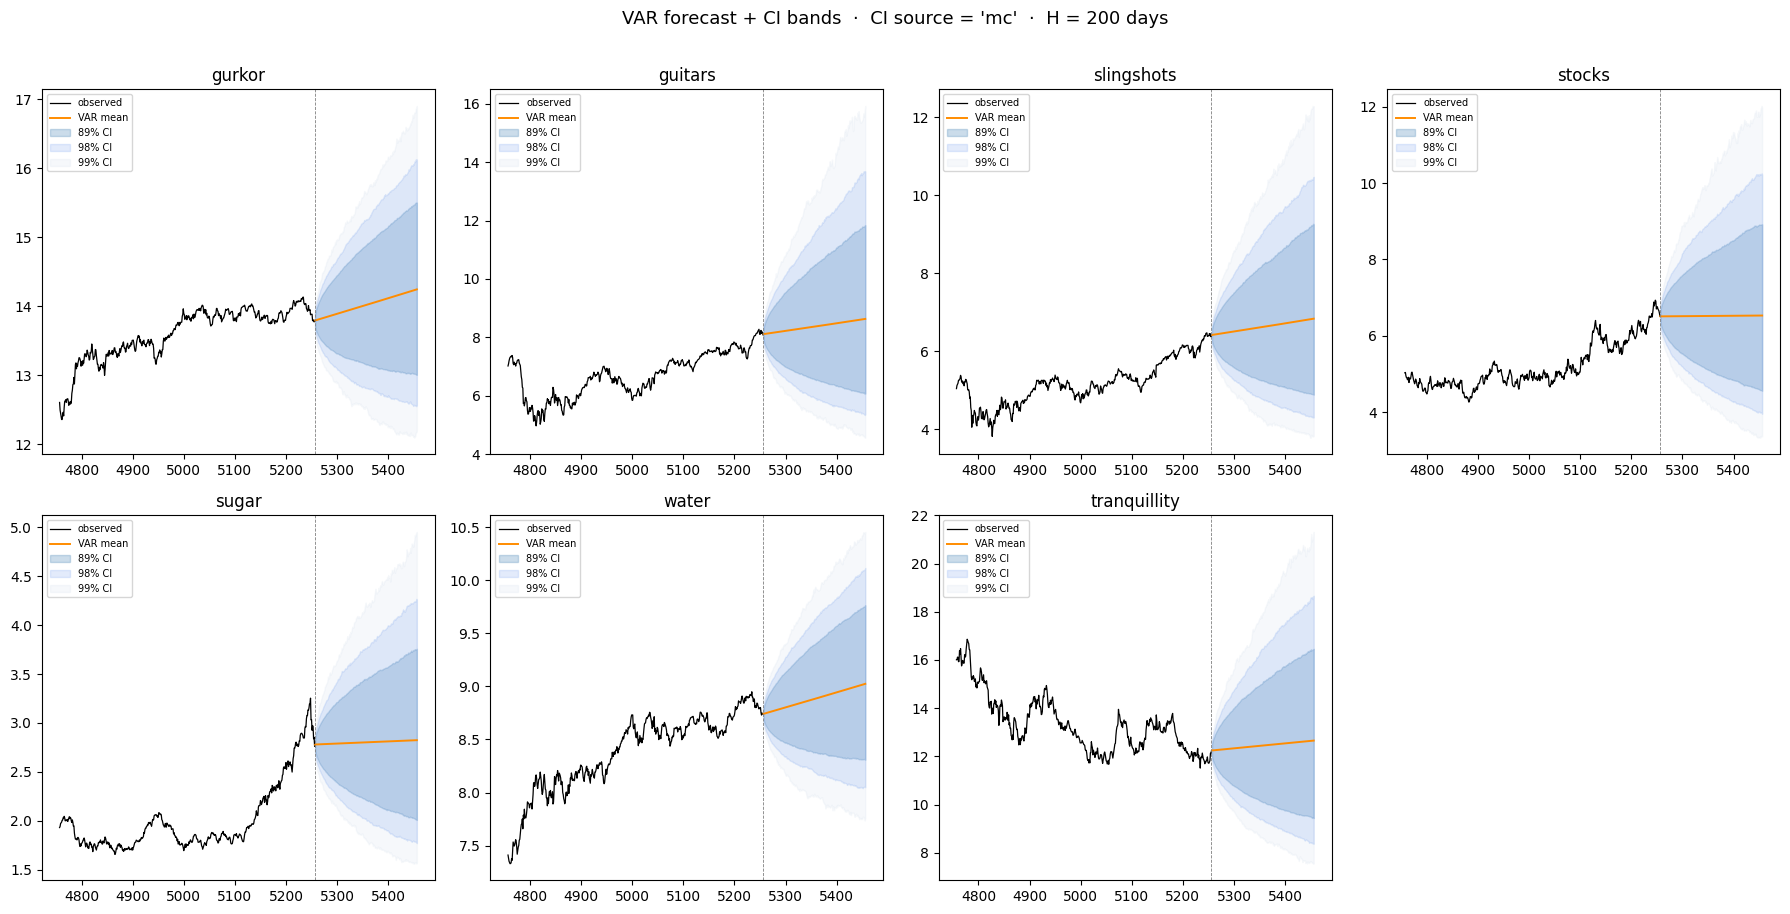

In [46]:
# Toggle: choose CI source.
CI_METHOD = 'mc'   # one of: 'gaussian', 'cf', 'empirical', 'mc'
CI_BANDS  = [(0.05, 0.95), (0.01, 0.99), (0.001, 0.999)]   # 90 / 98 / 99.8%

# Deterministic VAR forecast (innovations = 0) — the conditional mean path
Y_det = np.zeros((H_tail + 2, k))
Y_det[0] = Y[-2]
Y_det[1] = Y[-1]
for t in range(2, H_tail + 2):
    Y_det[t] = Phi1 @ Y_det[t - 1] + Phi2 @ Y_det[t - 2]
returns_det = Y_det[2:] + mean_return.values
prices_det  = last_price * np.cumprod(1.0 + returns_det, axis=0)

future_days_tail = np.arange(last_day + 1, last_day + 1 + H_tail)
t_axis = np.arange(1, H_tail + 1)

def terminal_log_quantile(method, j, a):
    """Terminal H_tail log-return quantile for series j at probability a."""
    key = f"{method}_{int(a*1000)/10}"
    return tail_df.loc[var_names[j], key]

def ci_band(method, j, a_lo, a_hi):
    """Return arrays (low, high) of price levels along t_axis."""
    P0 = last_price[j]
    if method == 'mc':
        low  = np.quantile(mc_prices[:, :, j], a_lo, axis=0)
        high = np.quantile(mc_prices[:, :, j], a_hi, axis=0)
    else:
        q_lo = terminal_log_quantile(method, j, a_lo)
        q_hi = terminal_log_quantile(method, j, a_hi)
        # sqrt-time scaling of the *log-return* quantile
        scale  = np.sqrt(t_axis / H_tail)
        # also scale the drift linearly with t
        mu_H   = tail_df.loc[var_names[j], 'mu_H']
        drift  = mu_H * t_axis / H_tail
        low_lr  = drift + (q_lo - mu_H) * scale
        high_lr = drift + (q_hi - mu_H) * scale
        low  = P0 * np.exp(low_lr)
        high = P0 * np.exp(high_lr)
    return low, high

# Plot
fig, axes = plt.subplots(2, 4, figsize=(18, 9), sharex=False)
tail_obs = 500
band_alphas = [0.28, 0.18, 0.10]
band_colors = ['steelblue', 'cornflowerblue', 'lightsteelblue']

for ax, col, j in zip(axes.flat, var_names, range(k)):
    ax.plot(df_prices.index[-tail_obs:], df_prices[col].iloc[-tail_obs:],
            color='black', lw=0.9, label='observed')
    ax.plot(future_days_tail, prices_det[:, j],
            color='darkorange', lw=1.4, label='VAR mean')

    for (a_lo, a_hi), fa, fc in zip(CI_BANDS, band_alphas, band_colors):
        low, high = ci_band(CI_METHOD, j, a_lo, a_hi)
        ax.fill_between(future_days_tail, low, high,
                        color=fc, alpha=fa,
                        label=f'{int((a_hi - a_lo) * 100)}% CI')

    ax.axvline(last_day, color='grey', lw=0.6, ls='--')
    ax.set_title(col)
    ax.legend(fontsize=7, loc='best')
axes.flat[-1].axis('off')
plt.suptitle(f"VAR forecast + CI bands  ·  CI source = '{CI_METHOD}'  ·  H = {H_tail} days",
             y=1.01, fontsize=13)
plt.tight_layout()
plt.show()